# LightGBMM Regression Playground

Interactive environment to step through the `lightgbm_recursive.py` pipeline for Retail Forecasting.

In [11]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Point to project root
PROJECT_ROOT = os.path.dirname(os.path.abspath(''))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.models.lightgbm_recursive import (
    load_processed_data,
    preprocess_and_split, 
    train_models, 
    predict_models, 
    evaluate_models,
    save_artifacts
)
from src.tools import plot_cluster_portfolio, analyze_time_periods, plot_mape_vs_volume

## 1. Load Processed Data

In [12]:
data_path = os.path.join(PROJECT_ROOT, 'data', 'processed_retail_data.parquet')
df_long = load_processed_data(data_path)
df_long.head()

Loading processed data...


,StockCode,Week,Quantity,Revenue,week_of_year,month,quarter,year,sin_woy,cos_woy,...,volume_tier,semantic_cluster_name,ADI,CV2,demand_class,share_zero_weeks,price_median,mean_basket_size,n_unique_customers,country_uk_share
0,10080,2009-11-30,4,3.4,49,11,4,2009,-3.546049e-01,0.935016,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0
1,10080,2009-12-07,0,0.0,50,12,4,2009,-2.393157e-01,0.970942,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0
2,10080,2009-12-14,0,0.0,51,12,4,2009,-1.205367e-01,0.992709,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0
3,10080,2009-12-21,0,0.0,52,12,4,2009,6.432491e-16,1.000000,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0
4,10080,2009-12-28,0,0.0,53,12,4,2009,1.205367e-01,0.992709,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0


## 2. Preprocess & Split
Scales the continuous features (MinMaxScaler) per StockCode and drops unnecessary columns.

In [13]:
train, test, X_train, y_train, X_test, feature_cols = preprocess_and_split(df_long)
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Feature Engineering and Train/Test Split...
Applying Global Scaling (Log1p for volumes, MinMax for ratios)...
Training shape: (186915, 26)
Testing shape:  (35798, 26)
Train shape: (186915, 26)
Test shape: (35798, 26)


## 3. Train Models per Seasonal Profile

In [14]:
cluster_models = train_models(X_train, y_train, train)

Training LightGBM models per Seasonal Profile Cluster (Tweedie Objective)...
 - Model for Cluster 0 trained on 34327 historical rows.
 - Model for Cluster 1 trained on 21779 historical rows.
 - Model for Cluster 2 trained on 57082 historical rows.
 - Model for Cluster 3 trained on 73727 historical rows.


## 4. Predict on Test Set

In [15]:
test = predict_models(cluster_models, test, X_test)

Predicting on Test Set...
Applying physical constraints (Capping at 0)...
Predictions Complete!


## 5. Evaluate

In [16]:
cluster_eval, summary = evaluate_models(test)
summary


Evaluating model (raw Quantity)...


,WMAPE,Median_MAPE,Mean_Absolute_Error
Cluster,,,
Global,59.02,55.75,32.05
0,69.61,61.49,10.94
1,64.54,58.23,41.38
2,56.25,55.84,39.55
3,56.37,52.13,29.90


## 6. Visualization

/Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/src/tools/visualization.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sku_stats = c_data.groupby("StockCode", observed=True).apply(
/Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/src/tools/visualization.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sku_stats 

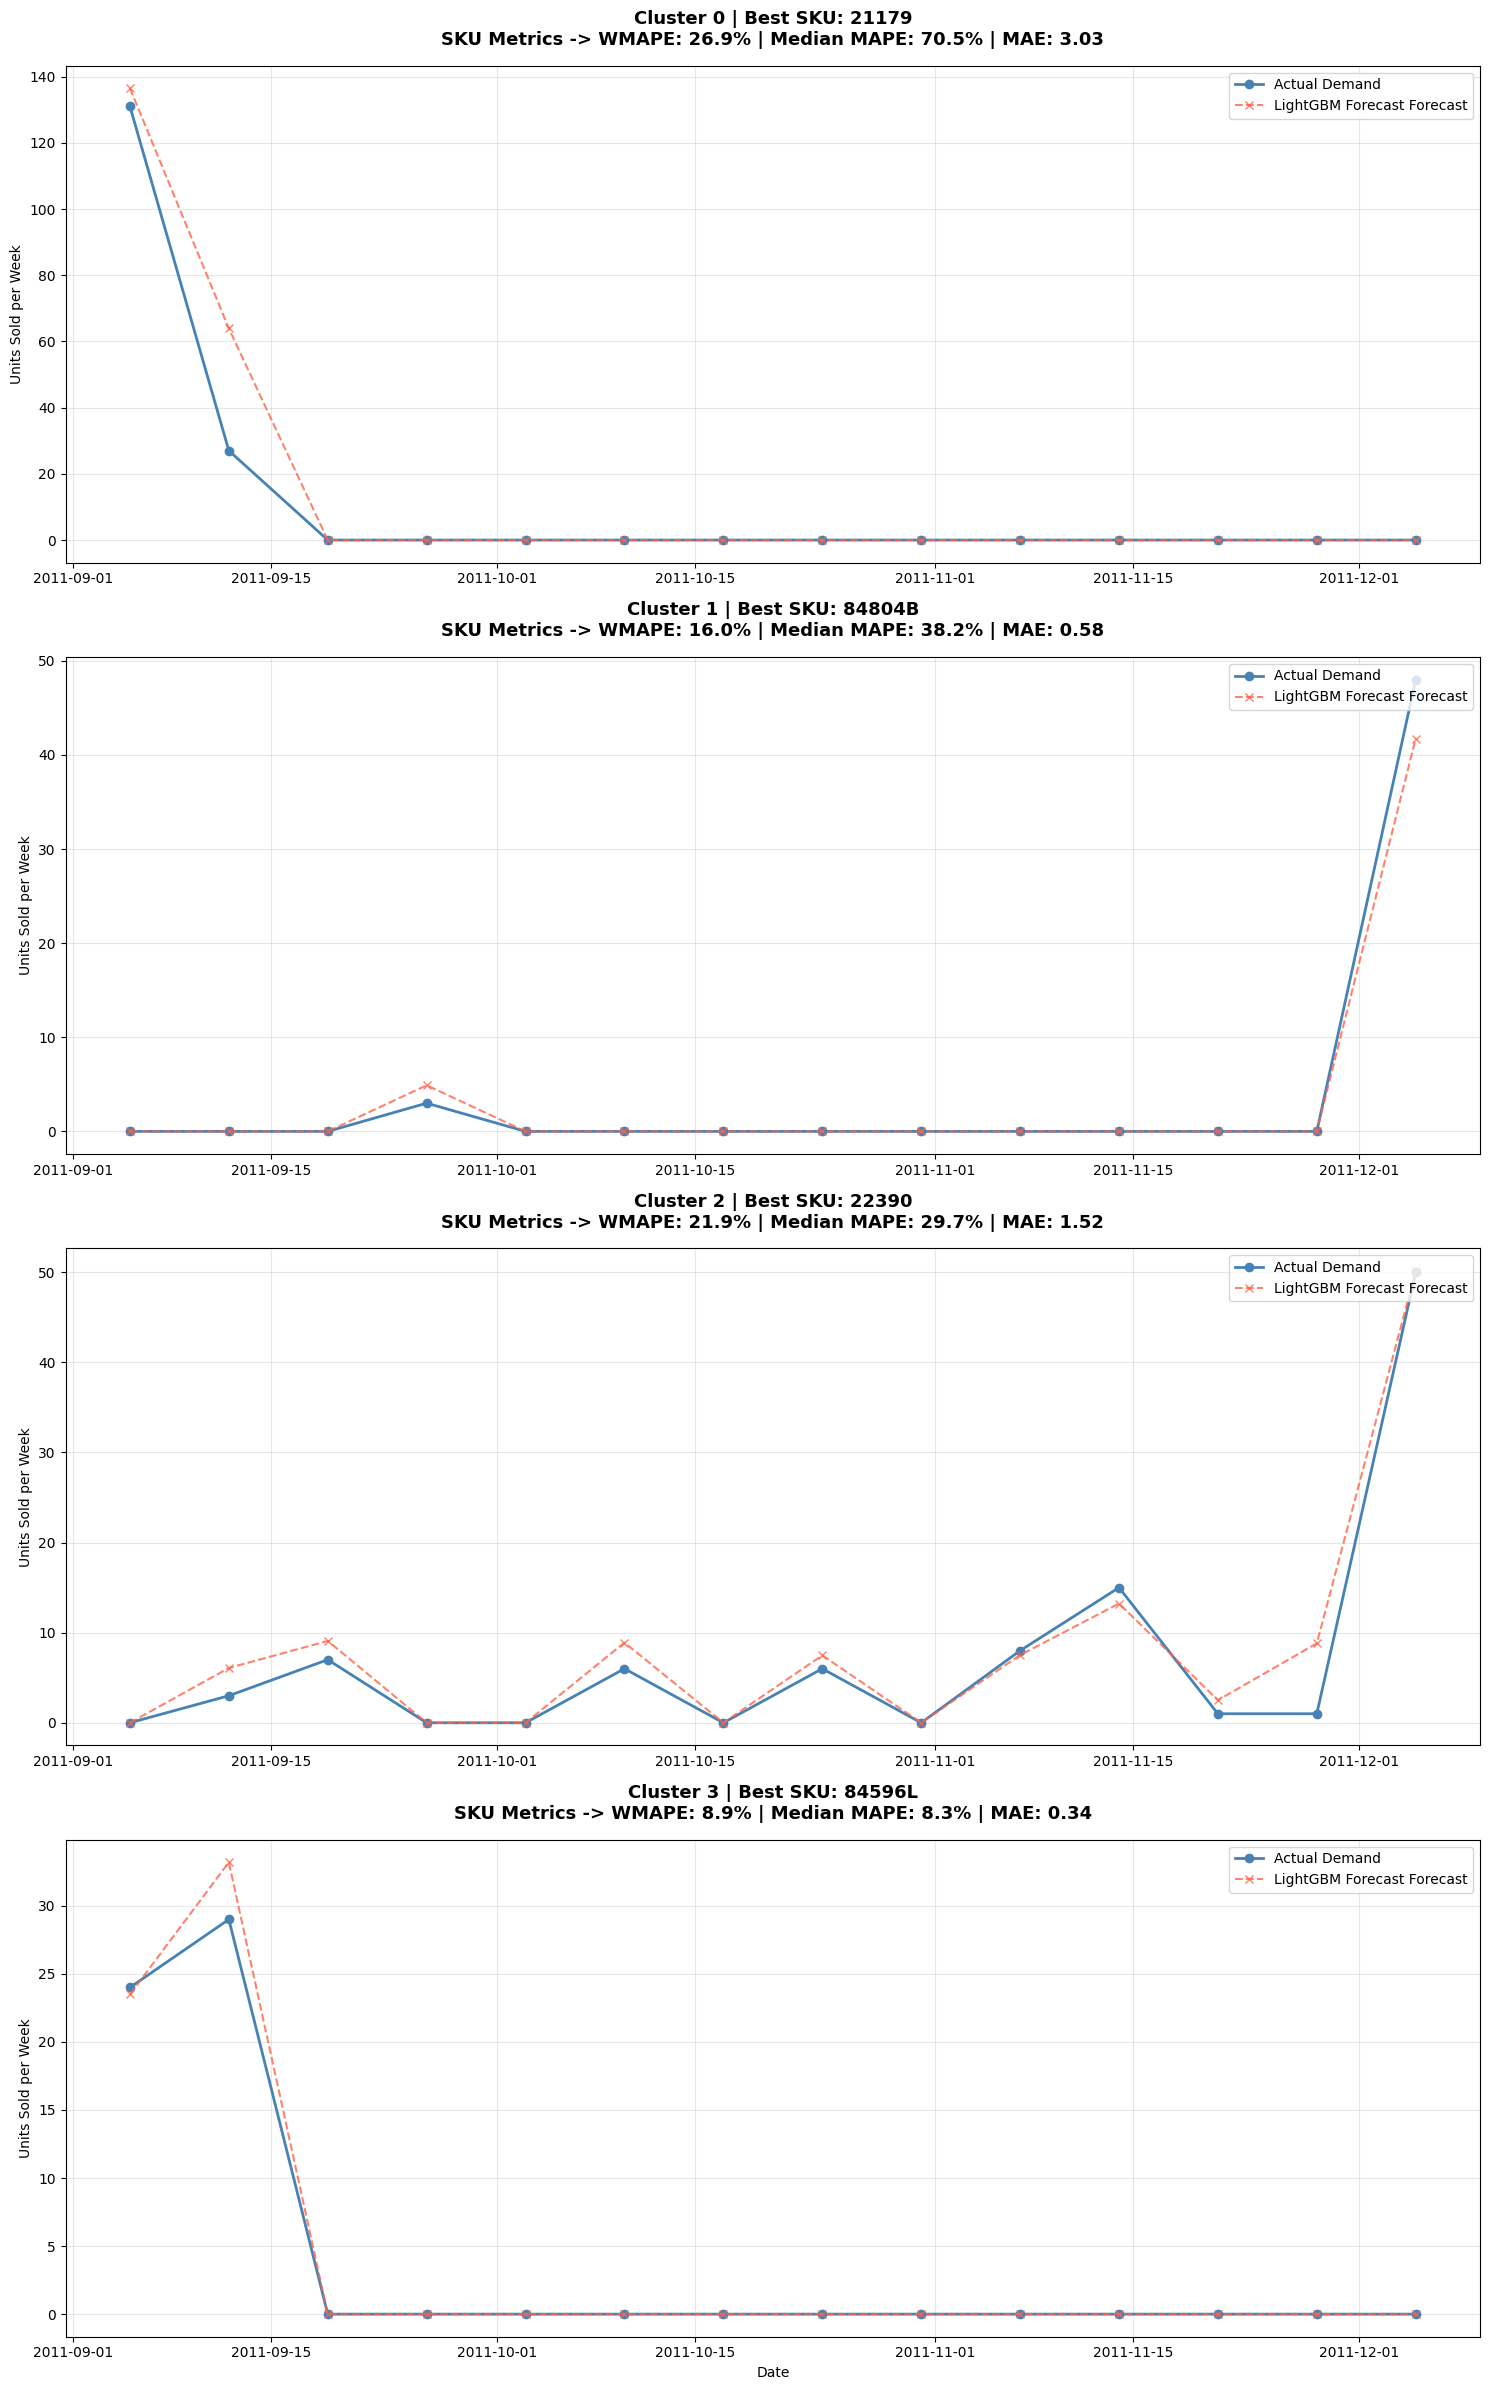

/Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/src/tools/visualization.py:188: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sku_metrics = cluster_eval.groupby("StockCode", observed=True).apply(calc_sku_metrics).dropna()
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning:

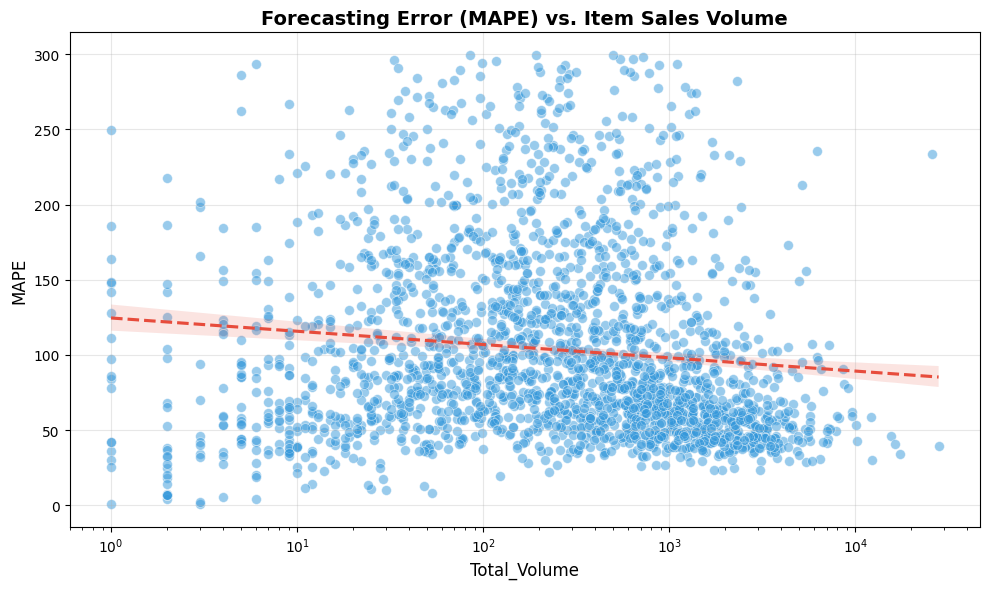

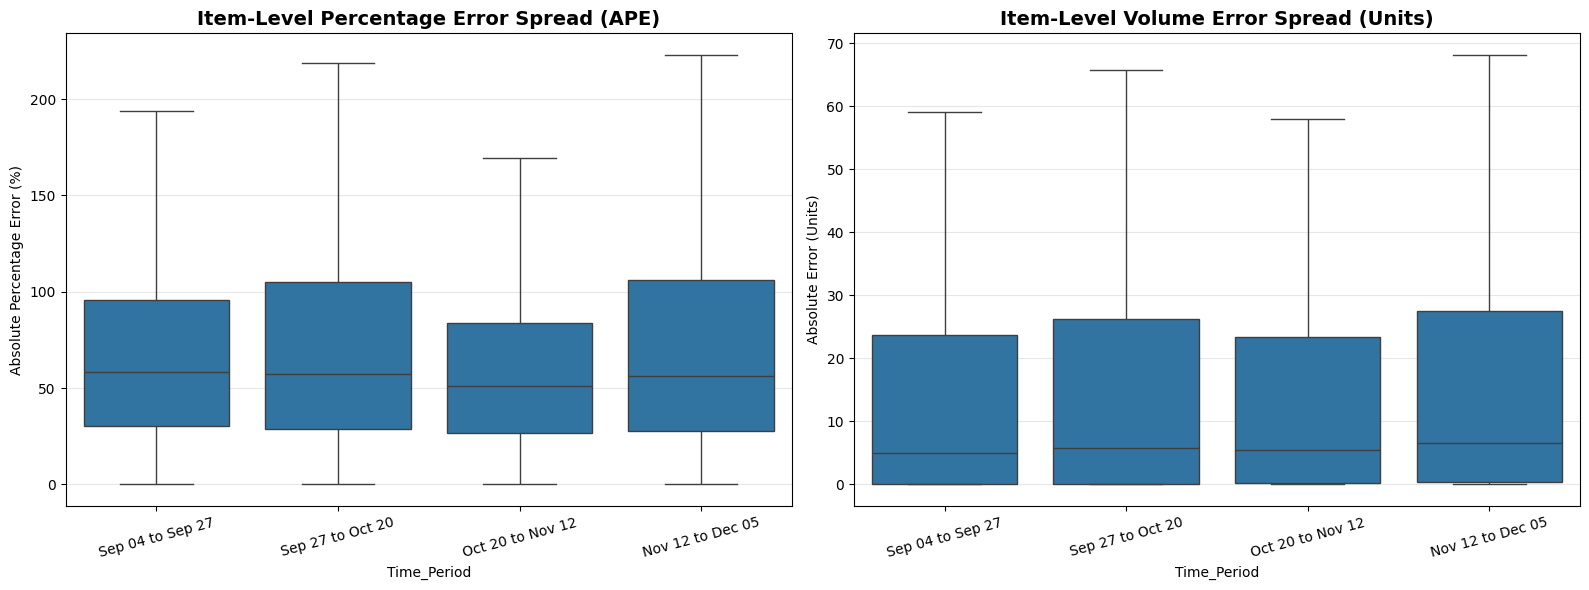

,WMAPE,Median_MAPE,Mean_Absolute_Error
Time_Period,,,
Sep 04 to Sep 27,60.41,58.34,29.70
Sep 27 to Oct 20,59.93,57.35,30.98
Oct 20 to Nov 12,57.18,51.15,33.43
Nov 12 to Dec 05,58.62,56.38,34.17


In [17]:
plot_cluster_portfolio(cluster_eval, summary, model_label="LightGBM Forecast")
plot_mape_vs_volume(cluster_eval)

# Analyze the drift of error over time
analyze_time_periods(test)

# Save Artifacts

In [18]:
sku_clusters = df_long.drop_duplicates(subset=['StockCode']).set_index('StockCode')['profile_cluster_id'].to_dict()
save_artifacts(cluster_models, feature_cols, sku_clusters, artifacts_dir=os.path.join(PROJECT_ROOT, 'agent', 'artifacts'))

Saving Cluster LightGBM artifacts to /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/agent/artifacts...
Successfully saved /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/agent/artifacts/lgb_cluster_models.pkl
